## Wrangling data for the Duke Uconn game visualization

Play-by-play data from [ESPN](https://www.espn.com/mens-college-basketball/playbyplay/_/gameId/401856577)

In [27]:
import pandas as pd
from plotnine import *
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['svg.fonttype'] = 'none'

I'm reading in the data I entered into google sheets and saved as a CSV here. I specify that minutes and seconds should remain strings so that I retain the double zeros/leading zeros when either of those columns get below 10. 

In [4]:
df = pd.read_csv('data/duke_uconn_game.csv', dtype={'minutes':str, 'seconds':str})

I make a `min_sec` column in the hopes I can natively in Plotnine make these my labels while plotting my x axis on `universal` (the variable I created that starts at 1 and increase 1 for each second in the game, making sure each second has a unique identifier)

In [5]:
df['min_sec'] = df['minutes'].astype(str) + ":" + df['seconds'].astype(str)

In [6]:
df.head()

,half,minutes,seconds,universal,uconn,duke,diff,individual_points,player,team,min_sec
0,1,20,00,1,0,0,0,0,NaN,NaN,20:00
1,1,19,59,2,0,0,0,0,NaN,NaN,19:59
2,1,19,58,3,0,0,0,0,NaN,NaN,19:58
3,1,19,57,4,0,0,0,0,NaN,NaN,19:57
4,1,19,56,5,0,0,0,0,NaN,NaN,19:56


I also made the only_minutes variable that takes the `universal` number for each second where the `second` column is at 00 (when each minute ends). This way I can neatly map them as my x-axis labels and can then manually change them when I bring the plot into Illustrator for cleaning.

I originally was going to use the `breaks=range(start,end,breaks)` syntax, but, because each half starts at "20:00", it throws off the universal number by one when the second half starts. *(eg. I could do `breaks=range(1,1201,60)` and it would accurately map the minute-end increments for the first half with the last tick at exactly "00:00" for the first half. But, because the second half starts first at "20:00" before going to "19:59", the universal number for "19:00" in the second half is actually 1262, not 1261 (a 61-number difference from the previous label)).*

In [ ]:
only_minutes = df[df['seconds']=="00"]['universal'].to_list()
only_minutes

[1,
 61,
 121,
 181,
 241,
 301,
 361,
 421,
 481,
 541,
 601,
 661,
 721,
 781,
 841,
 901,
 961,
 1021,
 1081,
 1141,
 1201,
 1202,
 1262,
 1322,
 1382,
 1442,
 1502,
 1562,
 1622,
 1682,
 1742,
 1802,
 1862,
 1922,
 1982,
 2042,
 2102,
 2162,
 2222,
 2282,
 2342,
 2402]

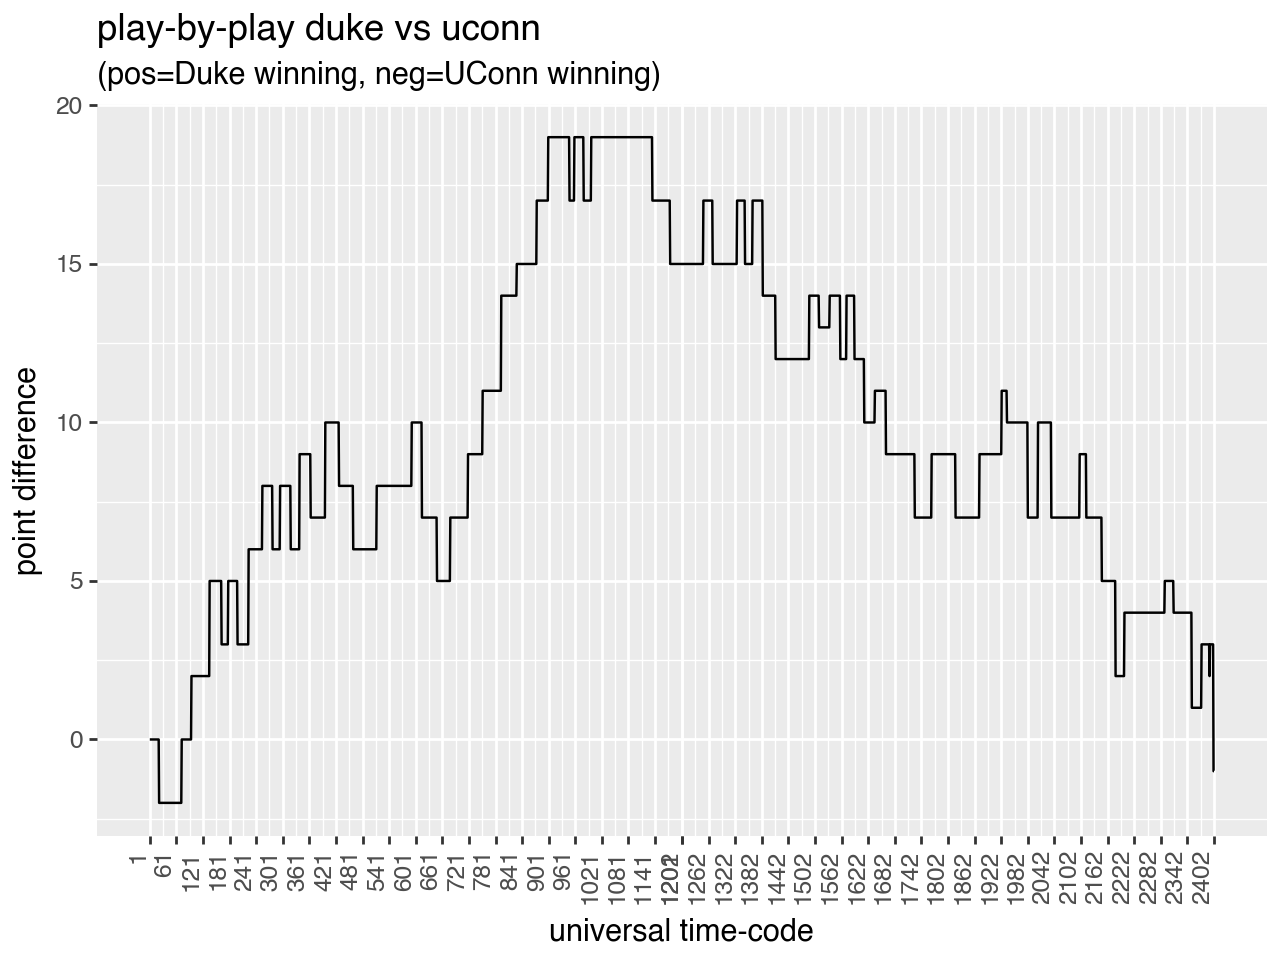

In [ ]:
plot = (
    ggplot(df) +
    aes(x='universal', y='diff') +
    geom_line() +
    scale_x_continuous(breaks=only_minutes) +
    theme(axis_text_x=element_text(rotation=90, hjust=1)) +
    labs(title="play-by-play duke vs uconn",
         subtitle="(pos=Duke winning, neg=UConn winning)",
         x="universal time-code",
         y='point difference')
)
plot

In [ ]:
plot.save('from_ggplot_points.svg')

/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: from_ggplot_points.svg


I am also interested in some by-team stats. First I want to find UConn and Duke's longest scoring droughts in the game

In [ ]:
df_uconn_only = df[df['team']=='Uconn']

In [ ]:
df_uconn_only.head()

,half,minutes,seconds,universal,uconn,duke,diff,individual_points,player,team,min_sec
21,1,19,39,22,2,0,-2,2,Tarris Reed Jr,Uconn,19:39
162,1,17,18,163,4,7,3,2,Tarris Reed Jr,Uconn,17:18
198,1,16,42,199,6,9,3,2,Solo Ball,Uconn,16:42
277,1,15,23,278,8,14,6,2,Tarris Reed Jr,Uconn,15:23
318,1,14,42,319,10,16,6,2,Tarris Reed Jr,Uconn,14:42


In [ ]:
df_uconn_only['scoring_droughts'] = df_uconn_only['universal'].shift(-1) - df_uconn_only['universal']

/var/folders/0c/3z452hlj1pzb2yr_79hcgh8r0000gn/T/ipykernel_92139/2404996266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


UConn's longest scoring drough seems to have been **299 seconds (4:59) ending at 09:12 in the first half**

In [ ]:
df_uconn_only.sort_values('scoring_droughts', ascending=False).head()

,half,minutes,seconds,universal,uconn,duke,diff,individual_points,player,team,min_sec,scoring_droughts
648,1,09,12,649,21,26,5,2,Silas Demary Jr,Uconn,09:12,299.0
459,1,12,21,460,16,22,6,2,Tarris Reed Jr,Uconn,12:21,155.0
979,1,03,41,980,25,42,17,2,Malachi Smith,Uconn,03:41,155.0
21,1,19,39,22,2,0,-2,2,Tarris Reed Jr,Uconn,19:39,141.0
2179,2,03,42,2180,65,67,2,3,Solo Ball,Uconn,03:42,131.0


In [ ]:
print("UConn scoring droughts:")
print("Mean: ", df_uconn_only['scoring_droughts'].mean())
print("Median: ", df_uconn_only['scoring_droughts'].median())

UConn scoring droughts:
Mean:  69.97058823529412
Median:  47.5


<hr>

In [ ]:
df_duke_only = df[df['team']=='Duke']

In [ ]:
df_duke_only['scoring_droughts'] = df_duke_only['universal'].shift(-1) - df_duke_only['universal']

/var/folders/0c/3z452hlj1pzb2yr_79hcgh8r0000gn/T/ipykernel_92139/4043281736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Duke's longest scoring drought lasted **253 seconds (04:13) and ended at 03:24 in the first half**

In [ ]:
df_duke_only.sort_values('scoring_droughts', ascending=False).head()

,half,minutes,seconds,universal,uconn,duke,diff,individual_points,player,team,min_sec,scoring_droughts
996,1,03,24,997,25,44,19,2,Cayden Boozer,Duke,03:24,253.0
1636,2,12,45,1637,45,56,11,1,Cameron Boozer,Duke,12:45,128.0
1360,2,17,21,1361,33,50,17,2,Patrick Ngongba II,Duke,17:21,128.0
396,1,13,24,397,12,22,10,3,Cayden Boozer,Duke,13:24,116.0
1764,2,10,37,1765,49,58,9,2,Cameron Boozer,Duke,10:37,108.0


In [ ]:
print("Duke scoring droughts:")
print("Mean: ", df_duke_only['scoring_droughts'].mean())
print("Median: ", df_duke_only['scoring_droughts'].median())

Duke scoring droughts:
Mean:  67.67647058823529
Median:  48.0


In [ ]:
df_uconn_scoring_drought = df[(df['universal']>=649) & (df['universal']<=947)]

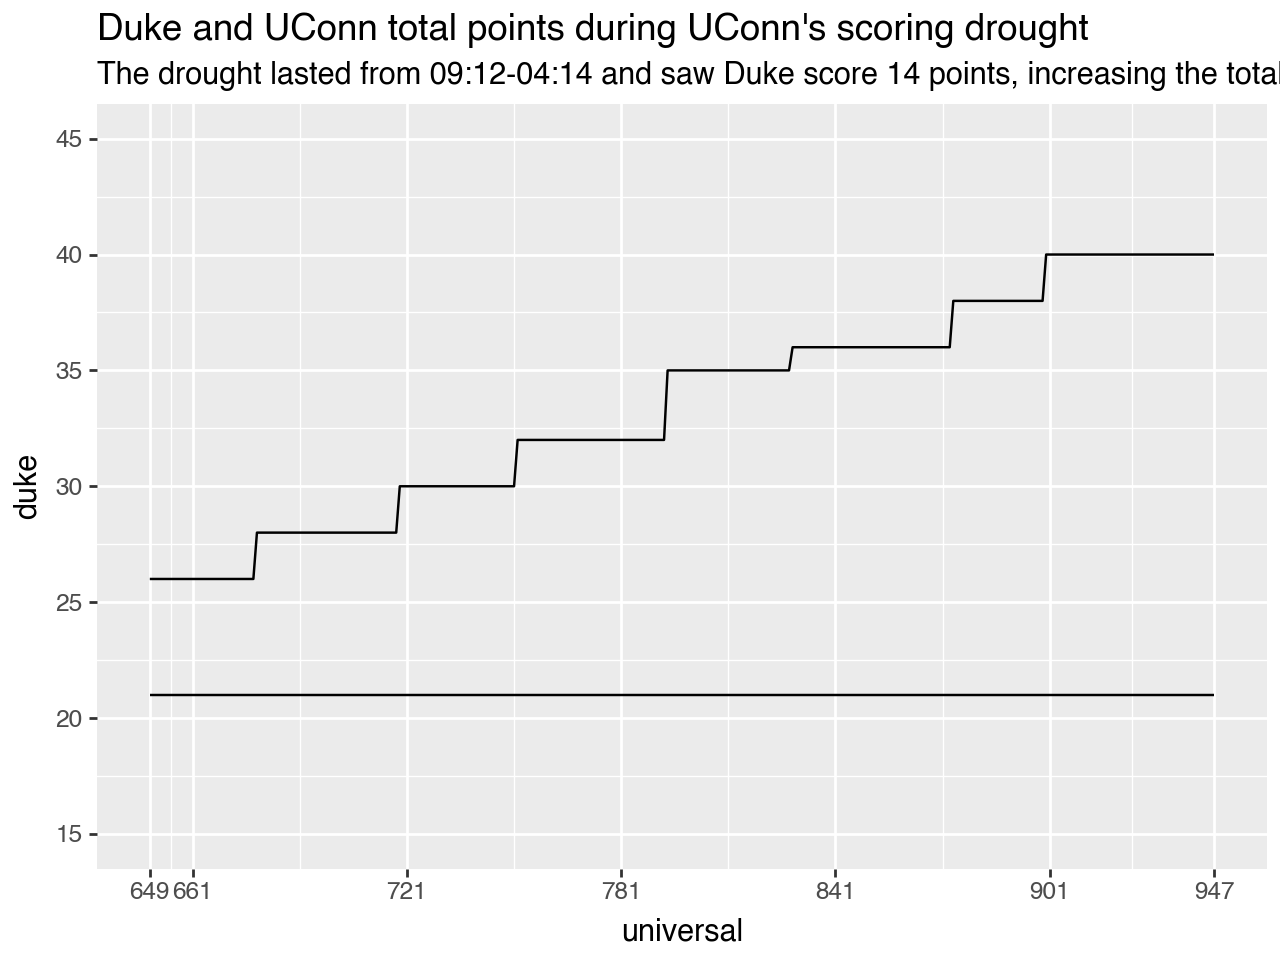

In [ ]:
plot = (
    ggplot(df_uconn_scoring_drought) +
    geom_line(aes(x='universal', y='duke')) +
    geom_line(aes(x='universal', y='uconn')) +
    scale_y_continuous(limits=(15,45),breaks=[15,20,25,30,35,40,45], labels=[15,20,25,30,35,40,45]) +
    scale_x_continuous(breaks=[649,661,721,781,841,901,947], labels=[649,661,721,781,841,901,947]) +
    labs(title="Duke and UConn total points during UConn's scoring drought",
         subtitle="The drought lasted from 09:12-04:14 and saw Duke score 14 points, increasing the total point gap from 5 to 19")
)
plot

<hr>

One of my visuals – for the halftime point in the game – is going to be a bar chart of top scorers in the first half. Below I'm making a dataframe that only has each player's first half points

In [30]:
df_first_half_points = df[(df['half']==1) & (df['player'].notna())]
df_first_half_top_scorers = df_first_half_points.groupby('player', as_index=False).agg({
    'team': 'first',
    'individual_points': 'sum'
    })

In [31]:
df_first_half_top_scorers.sort_values('individual_points', ascending=False)

,player,team,individual_points
1,Cameron Boozer,Duke,14
2,Cayden Boozer,Duke,13
11,Tarris Reed Jr,Uconn,12
3,Dame Sarr,Duke,8
6,Malachi Smith,Uconn,7
5,Isaiah Evans,Duke,5
10,Solo Ball,Uconn,4
0,Braylon Mullins,Uconn,2
4,Eric Reibe,Uconn,2
7,Nikolas Khamenia,Duke,2


In [34]:
conditions = [
    df_first_half_top_scorers['player'].str.contains('Boozer'),
    df_first_half_top_scorers['team'].str.contains('Uconn')
]

choices = ['Boozer', 'UConn']

df_first_half_top_scorers['group'] = np.select(conditions, choices, default='Duke Other')

In [39]:
df_first_half_top_scorers.sort_values('individual_points', ascending=False)

,player,team,individual_points,group
1,Cameron Boozer,Duke,14,Boozer
2,Cayden Boozer,Duke,13,Boozer
11,Tarris Reed Jr,Uconn,12,UConn
3,Dame Sarr,Duke,8,Duke Other
6,Malachi Smith,Uconn,7,UConn
5,Isaiah Evans,Duke,5,Duke Other
10,Solo Ball,Uconn,4,UConn
0,Braylon Mullins,Uconn,2,UConn
4,Eric Reibe,Uconn,2,UConn
7,Nikolas Khamenia,Duke,2,Duke Other


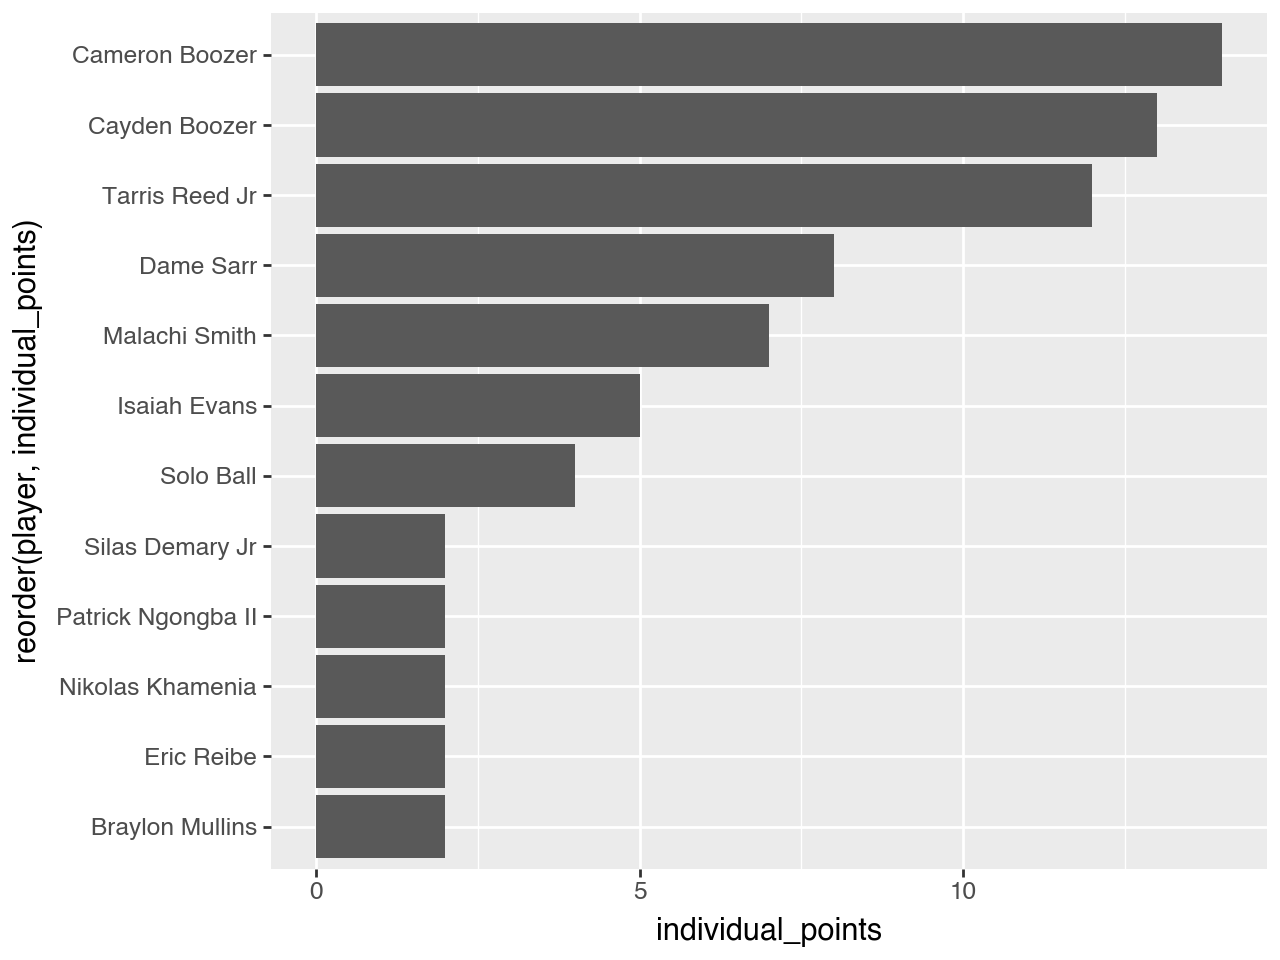

In [52]:
plot = (
    ggplot(df_first_half_top_scorers) +
    aes(y='individual_points', x='reorder(player, individual_points)') +
    coord_flip() +
    geom_bar(stat='identity')
)

plot

In [40]:
df_first_half_groups = df_first_half_top_scorers.groupby('group', as_index=False)['individual_points'].sum()

In [42]:
df_first_half_groups.sort_values('individual_points', ascending=False)

,group,individual_points
2,UConn,29
0,Boozer,27
1,Duke Other,17


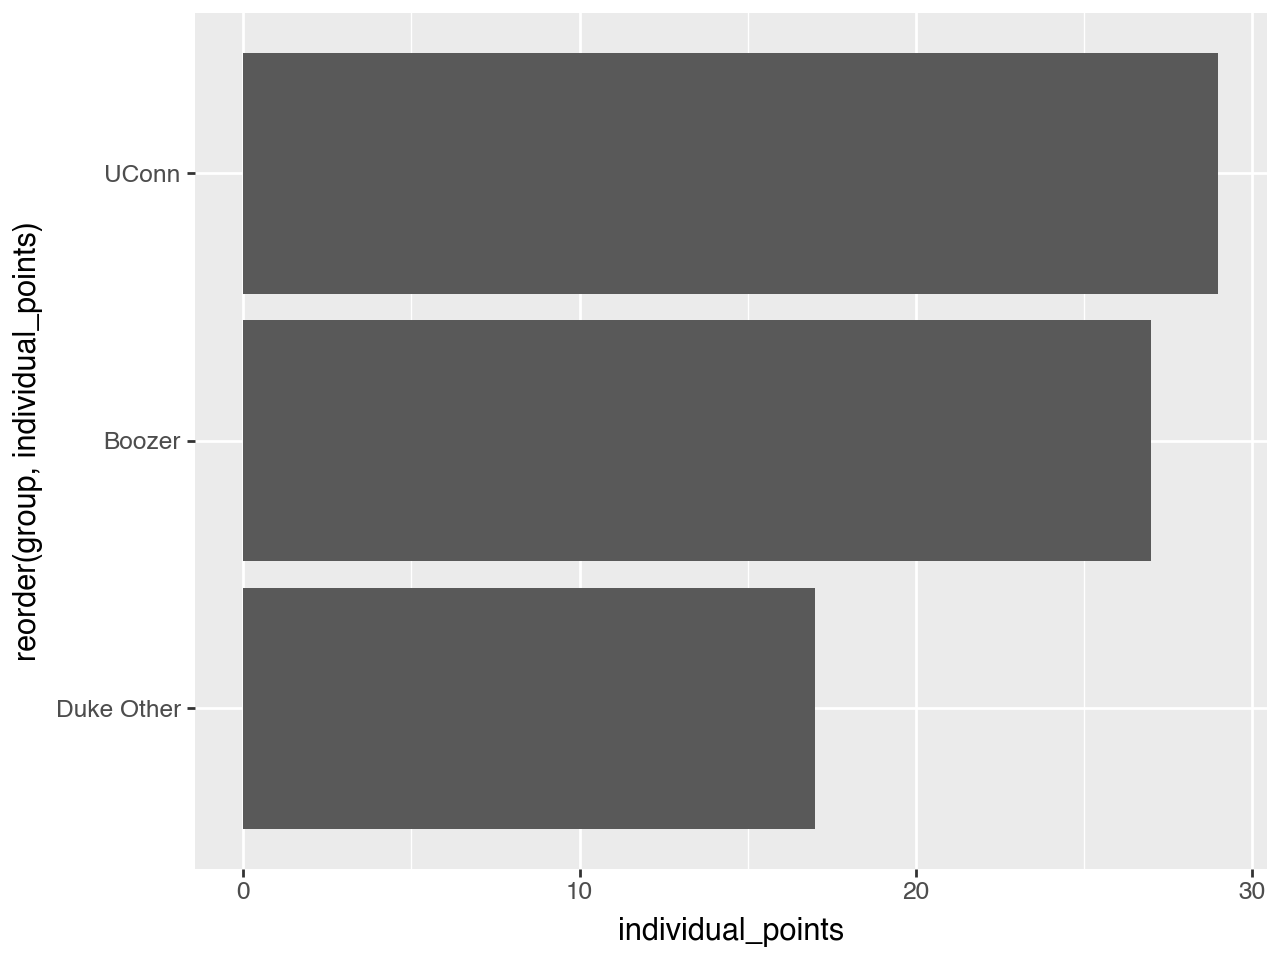

In [51]:
plot = (
    ggplot(df_first_half_groups) +
    aes(y='individual_points', x='reorder(group, individual_points)') +
    coord_flip() +
    geom_bar(stat='identity')
)

plot

In [ ]:
plot.save('from_ggplot_points.svg')